In [1]:
import sys
sys.path.append('../../1_figure_CL_proof_of_concept/code/')
import utils_00 as gf_utils

import pandas as pd
import numpy as np

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
import matplotlib.pyplot as plt


In [3]:
expected_mutations = pd.read_csv('../../4_figure_MPN_metrics/data/MPN_expected_mutations.csv')[['sample','name','mutation_freq']]
expected_mutations.rename(columns={'mutation_freq': 'expected_frequency_from_bulk'}, inplace=True)

expected_mutations['HGVSc'] = expected_mutations['name'].str.split(' ').str[1]
expected_mutations['gene'] = expected_mutations['name'].str.split(' ').str[0]

### drop mutations with 0 expected frequency (these were annotated by mistake)
expected_mutations = expected_mutations.loc[expected_mutations['expected_frequency_from_bulk'] > 0]

In [6]:
dir = '../../4_figure_MPN_metrics/data/unexpected_gapfills/'

### load in tables of all gapfills seen in each library
merged_table_1 = gf_utils.make_merge_table(dir + 'unexpected_gapfills_1', label_control_column=True, lib='1', control_idx = '16')
merged_table_2 = gf_utils.make_merge_table(dir + 'unexpected_gapfills_2', label_control_column=True, lib='2', control_idx = '15')
merged_table_4plex = gf_utils.make_merge_table(dir + 'unexpected_gapfills_4plex', label_control_column=False, lib='4plex')
merged_table_1plex = gf_utils.make_merge_table(dir + 'unexpected_gapfills_1plex', label_control_column=False, lib='1plex')

In [7]:
merge_columns = ['gapfill', 'gapfill_from_transcriptome','gapfill_start','gap_probe_sequence','likelihood_given_wt_edit_dist','lhs_probe','rhs_probe']

# Merge only if the DataFrames are not empty
if not merged_table_2.empty:
    merged_table = merged_table_1.merge(merged_table_2, on=merge_columns, how='outer')
else:
    merged_table = merged_table_1.copy()

if not merged_table_4plex.empty:
    merged_table = merged_table.merge(merged_table_4plex, on=merge_columns, how='outer')

if not merged_table_1plex.empty:
    merged_table = merged_table.merge(merged_table_1plex, on=merge_columns, how='outer')
    
### manual fix for dual probes
merged_table.loc[(merged_table['lhs_probe'] == 'ATTTAGAGGATAAGGCGGCAGTAGT') & (merged_table['rhs_probe'] == 'TGTGTTCGCTGTAGATCTGACGTAC'),'rhs_probe'] = 'TGTGTTCGCTGTAGATCTGACGTAC/TGTGTAAGGCGGCAGTAGTTGTGTT'
merged_table.loc[(merged_table['lhs_probe'] == 'ATTTAGAGGATAAGGCGGCAGTAGT') & (merged_table['rhs_probe'] == 'TGTGTAAGGCGGCAGTAGTTGTGTT'),'rhs_probe'] = 'TGTGTTCGCTGTAGATCTGACGTAC/TGTGTAAGGCGGCAGTAGTTGTGTT'
merged_table.loc[(merged_table['rhs_probe'] == 'AATAGCTCATTAAAGTCATCTACCG') & (merged_table['lhs_probe'] == 'GCTGGCTGTCAGCGGGTACCTTGCC'),'lhs_probe'] = 'GCTGGCTGTCAGCGGGTACCTTGCC/GCTCTCTGTCAGCGGGTACCTTGCC'
merged_table.loc[(merged_table['rhs_probe'] == 'AATAGCTCATTAAAGTCATCTACCG') & (merged_table['lhs_probe'] == 'GCTCTCTGTCAGCGGGTACCTTGCC'),'lhs_probe'] = 'GCTGGCTGTCAGCGGGTACCTTGCC/GCTCTCTGTCAGCGGGTACCTTGCC'


merged_table = gf_utils.sum_probe_counts(merged_table)


In [9]:
## reformat table to long format - 1 row for each sample/gapfill/probe combination

id_vars = list(merge_columns) + list(merged_table.columns[merged_table.columns.str.contains('control')])
value_vars = merged_table.columns.drop(id_vars)

samples = value_vars.str.split('probe_idx_').str[1].dropna().unique()
print('samples to parse:', samples)

dfs = []
for sample in samples:
    df_tmp = merged_table[id_vars].copy()
    for col in value_vars:
        if col.endswith(sample):
            df_tmp[col.replace('_' + sample, '')] = merged_table[col]
    df_tmp['sample'] = sample
    dfs.append(df_tmp)

merged_long = pd.concat(dfs, ignore_index=True)

merged_long['original_name'] = merged_long['name'].copy()

### manual fix for extra added probes
merged_long['name'] = merged_long['name'].str.replace('_extra','')
### manual fix for TET2 c.3218G>A
merged_long.loc[merged_long['name'] == 'TET2 c.3218G>A','gapfill_start'] = '3217'

## drop rows where probe_idx is NaN
merged_long = merged_long.loc[merged_long['probe_idx'].notna()]

### add HGVSc based on observed gapfill
merged_long = gf_utils.name_variants_by_gapfill(merged_long, expected_mutations, merge_columns)

## reorder columns for better interpretability
cols = ['name','HGVSc'] + merge_columns + [col for col in merged_long.columns if col not in (['name','HGVSc'] + merge_columns)]
merged_long = merged_long[cols]

## manual fix for dual probes
merged_long.loc[(merged_long['name'] == 'ASXL1 c.2081_2099dup_0') & (merged_long['gapfill'] == '') & (merged_long['gapfill_start'].isna()),'HGVSc'] = 'ASXL1 c.2081_2099dup'
merged_long.loc[(merged_long['name'] == 'ASXL1 c.2081_2099dup_1') & (merged_long['gapfill'] == '') & (merged_long['gapfill_start'].notna()),'HGVSc'] = 'ASXL1 wildtype'
merged_long.loc[(merged_long['name'] == 'ASXL1 c.2081_2099dup_0') & (merged_long['gapfill'] == '') & (merged_long['gapfill_start'].isna()),'name'] = 'ASXL1 c.2081_2099dup'
merged_long.loc[(merged_long['name'] == 'ASXL1 c.2081_2099dup_1') & (merged_long['gapfill'] == '') & (merged_long['gapfill_start'].notna()),'name'] = 'ASXL1 c.2081_2099dup'

merged_long.loc[(merged_long['name'] == 'NFE2 c.782_785del_0') & (merged_long['gapfill'] == '') & (merged_long['gapfill_start'].isna()),'HGVSc'] = 'NFE2 c.782_785del'
merged_long.loc[(merged_long['name'] == 'NFE2 c.782_785del_1') & (merged_long['gapfill'] == '') & (merged_long['gapfill_start'].notna()),'HGVSc'] = 'NFE2 wildtype'
merged_long.loc[(merged_long['name'] == 'NFE2 c.782_785del_0') & (merged_long['gapfill'] == '') & (merged_long['gapfill_start'].isna()),'name'] = 'NFE2 c.782_785del'
merged_long.loc[(merged_long['name'] == 'NFE2 c.782_785del_1') & (merged_long['gapfill'] == '') & (merged_long['gapfill_start'].notna()),'name'] = 'NFE2 c.782_785del'
##

merged_long['frequency'] = merged_long['count_of_this_gapfill'] / merged_long['count_of_this_probe']


samples to parse: Index(['BC007_1', 'BC008_1', 'BC005_1', 'BC004_1', 'BC001_1', 'BC010_1',
       'BC012_1', 'BC015_1', 'BC009_1', 'BC014_1', 'BC006_1', 'BC011_1',
       'BC003_1', 'BC016_1', 'BC013_1', 'BC002_1', 'BC012_2', 'BC011_2',
       'BC004_2', 'BC015_2', 'BC003_2', 'BC002_2', 'BC010_2', 'BC001_2',
       'BC008_2', 'BC014_2', 'BC005_2', 'BC006_2', 'BC009_2', 'BC007_2',
       'BC013_2', 'BC016_2', 'BC003_4plex', 'BC002_4plex', 'BC004_4plex',
       'BC001_4plex', 'BC001_1plex'],
      dtype='object')
len merged long 42119
len merged long after merge 42119


In [10]:
### manually add splice variants
### this could be done from the spreadsheet; could be before mapping HGVSc and the wildtype would be assigned correctly (but splice variant HGVSc must be done after)

merged_long.loc[(merged_long['name'] == 'TP53 c.920-1G>A'),'gapfill_from_transcriptome'] = 'GCT'
merged_long.loc[(merged_long['name'] == 'TP53 c.920-1G>A') & (merged_long['gapfill'] == 'GCT'),'HGVSc'] = 'TP53 wildtype'
merged_long.loc[(merged_long['name'] == 'TP53 c.920-1G>A') & (merged_long['gapfill'] == 'GTT'),'HGVSc'] = 'TP53 c.920-1G>A'

merged_long.loc[(merged_long['name'] == 'TET2 c.4537+2T>G'),'gapfill_from_transcriptome'] = 'TTACC'
merged_long.loc[(merged_long['name'] == 'TET2 c.4537+2T>G') & (merged_long['gapfill'] == 'TTACC'),'HGVSc'] = 'TET2 wildtype'
merged_long.loc[(merged_long['name'] == 'TET2 c.4537+2T>G') & (merged_long['gapfill'] == 'TAACC'),'HGVSc'] = 'TET2 c.4537+3A>T'
merged_long.loc[(merged_long['name'] == 'TET2 c.4537+2T>G') & (merged_long['gapfill'] == 'TTCCC'),'HGVSc'] = 'TET2 c.4537+2T>G'

merged_long.loc[(merged_long['name'] == 'TP53 c.376-2A>G'),'gapfill_from_transcriptome'] = 'CTG'
merged_long.loc[(merged_long['name'] == 'TP53 c.376-2A>G') & (merged_long['gapfill'] == 'CTG'),'HGVSc'] = 'TP53 wildtype'
merged_long.loc[(merged_long['name'] == 'TP53 c.376-2A>G') & (merged_long['gapfill'] == 'CCG'),'HGVSc'] = 'TP53 c.376-2A>G'

merged_long.loc[(merged_long['name'] == 'NFE2 c.115-1G>A'),'gapfill_from_transcriptome'] = 'CCT'
merged_long.loc[(merged_long['name'] == 'NFE2 c.115-1G>A') & (merged_long['gapfill'] == 'CCT'),'HGVSc'] = 'NFE2 wildtype'
merged_long.loc[(merged_long['name'] == 'NFE2 c.115-1G>A') & (merged_long['gapfill'] == 'CTT'),'HGVSc'] = 'NFE2 c.115-1G>A'


In [11]:
### get likelihood of observed gapfills based on different models - edit distance, control sample, or all other samples
merged_long = gf_utils.get_likelihood_given_edit_distance(merged_long)
merged_long = gf_utils.get_likelihood_given_control_sample(merged_long)
merged_long['gapfill_start'] = merged_long['gapfill_start'].fillna('not_found')
merged_long = gf_utils.get_likelihood_given_all_other_samples(merged_long)


In [12]:
merged_long['signed_log_likelihood_given_wt_control'] = np.log10(merged_long['likelihood_given_wt_control'] + (1e-300)) * merged_long['proportion_greater_than_expected_from_control']
merged_long['signed_log_likelihood_given_other_samples'] = np.log10(merged_long['likelihood_given_other_samples'] + (1e-300)) * merged_long['proportion_greater_than_expected_from_others']
merged_long['signed_log_likelihood_given_wt_edit_dist'] = np.log10(merged_long['likelihood_observed_proportion_given_edit_dist'] + (1e-300)) * merged_long['proportion_greater_than_expected_from_edit_dist']

In [13]:
# Create a mapping dictionary from expected_mutations
expected_freq_mapping = expected_mutations.set_index(['sample', 'name'])['expected_frequency_from_bulk'].to_dict()

# Apply the mapping to create the new column
merged_long['expected_frequency_from_bulk'] = merged_long[['sample', 'HGVSc']].apply(
    lambda row: expected_freq_mapping.get((row['sample'], row['HGVSc']), np.nan), axis=1
)

In [14]:
mutated_df = merged_long.loc[~(merged_long['HGVSc'].fillna('').str.contains('wildtype'))]
print(f"Number of expected mutations included: {len(mutated_df.loc[mutated_df['expected_frequency_from_bulk'].notna()])}")


Number of expected mutations included: 139


In [16]:
def quantify_found_mutations(all_feature_sets, expected_mutations, print_result = True):
    """
    Quantify found mutations against expected mutations.
    Parameters:
    - all_feature_sets: DataFrame containing all feature sets.
    - expected_mutations: DataFrame containing expected mutations.
    Returns:
    - None
    """
    df = all_feature_sets.copy()
    true_positive = len(df.loc[df['expected_frequency_from_bulk'].notna()][['sample','HGVSc']].drop_duplicates())
    predicted_positive = len(df[['sample','HGVSc']].drop_duplicates())
    actual_positive = len(expected_mutations[['sample','name']].drop_duplicates())
    precision = true_positive / predicted_positive if predicted_positive > 0 else 0
    recall = true_positive / actual_positive if actual_positive > 0 else 0
    if print_result:
        print('Fraction of found mutations that were expected (precision):', precision)
        print('Fraction of expected mutations that were found (recall/sensitivity):', recall)
    else:
        return precision, recall

def get_precision_recall_curve(mutated_df, min_log_likelihoods, min_counts, expected_mutations, min_frequency = 0, min_ratio=0.3, cols = ['signed_log_likelihood_given_wt_control']):
    """
    Get precision-recall for curve for different likelihood columns.
    Parameters:
    - min_log_likelihoods: List of minimum log likelihoods to consider.
    - min_counts: List of minimum counts to consider.
    - expected_mutations: DataFrame containing expected mutations.
    Returns:
    - None
    """
    all_results_df = pd.DataFrame()
    for likelihood_column in cols:
        precisions = []
        recalls = []

        for min_ll in min_log_likelihoods:
            for min_count in min_counts:
                temp_features = []
                for sample in mutated_df['sample'].unique():
                    temp = gf_utils.get_feature_set(
                        mutated_df, sample,
                        likelihood_column= likelihood_column,
                        min_log_likelihood=min_ll,
                        min_count = min_count, min_frequency = min_frequency, min_ratio=min_ratio
                    )
                    temp_features.append(temp)
                features_df = pd.concat(temp_features, ignore_index=True)
                precision_i, recall_i = quantify_found_mutations(features_df, expected_mutations, print_result=False)
                precisions.append(precision_i)
                recalls.append(recall_i)
        # Store results in a DataFrame for this likelihood_column
        results_df = pd.DataFrame({
            'min_log_likelihood': np.repeat(min_log_likelihoods, len(min_counts)),
            'min_count': np.tile(min_counts, len(min_log_likelihoods)),
            'precision': precisions,
            'recall': recalls,
        })
        results_df['likelihood_column'] = likelihood_column
        all_results_df = pd.concat([all_results_df, results_df], ignore_index=True)
    return all_results_df


In [17]:
min_counts = 0
min_freq = 0.003

mutated_df_above_freq = mutated_df.loc[mutated_df['frequency'] > min_freq]
print(f"Number of expected mutations above frequency: {len(mutated_df_above_freq.loc[mutated_df_above_freq['expected_frequency_from_bulk'].notna()])}")

mutated_df_above_count = mutated_df.loc[mutated_df['count_of_this_gapfill'] > min_counts]
print(f"Number of expected mutations above count: {len(mutated_df_above_count.loc[mutated_df_above_count['expected_frequency_from_bulk'].notna()])}")

mutated_df_above_count_freq = mutated_df_above_count.loc[mutated_df_above_count['frequency'] > min_freq]
print(f"Number of expected mutations above count and frequency: {len(mutated_df_above_count_freq.loc[mutated_df_above_count_freq['expected_frequency_from_bulk'].notna()])}")

mutated_df_above_count_freq = mutated_df_above_count_freq.dropna(subset=['signed_log_likelihood_given_wt_control','signed_log_likelihood_given_other_samples','signed_log_likelihood_given_wt_edit_dist'])
print(f"Number of expected mutations above count and frequency with non-NA likelihoods: {len(mutated_df_above_count_freq.loc[mutated_df_above_count_freq['expected_frequency_from_bulk'].notna()])}")

Number of expected mutations above frequency: 128
Number of expected mutations above count: 131
Number of expected mutations above count and frequency: 128
Number of expected mutations above count and frequency with non-NA likelihoods: 101


In [18]:
min_log_likelihoods = [-299,-250,-200,-60,-50,-40,-30,-20,-15,-10,-5,0,30,60,90,120,150,180,210,240,270,300,310]

included_mutations = mutated_df_above_count_freq.loc[(mutated_df_above_count_freq['expected_frequency_from_bulk'].notna()),['sample','HGVSc']]

# Subset expected_mutations to only those included in included_mutations (matching sample and name/HGVSc)
expected_mutations_subset = expected_mutations.merge(
    included_mutations.rename(columns={'HGVSc': 'name'}), 
    on=['sample', 'name']
)

all_results = get_precision_recall_curve(
    mutated_df_above_count_freq, min_log_likelihoods, [min_counts], expected_mutations_subset, cols=['signed_log_likelihood_given_wt_control','signed_log_likelihood_given_other_samples','signed_log_likelihood_given_wt_edit_dist'])#, save=True, filename='../plots/precision_recall_feature_set.pdf'


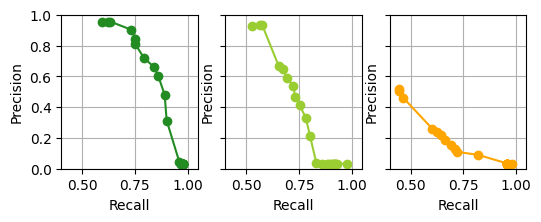

In [19]:
cols=['signed_log_likelihood_given_wt_control','signed_log_likelihood_given_other_samples','signed_log_likelihood_given_wt_edit_dist']
colors = {'signed_log_likelihood_given_wt_control': 'forestgreen', 'signed_log_likelihood_given_other_samples': 'yellowgreen', 'signed_log_likelihood_given_wt_edit_dist': 'orange'}

fig,(ax1,ax2,ax3) = plt.subplots(1,3,figsize=(6,2), sharex=True, sharey=True)

for likelihood_column,ax in zip(cols, [ax1,ax2,ax3]):
    recalls = all_results.loc[all_results['likelihood_column'] == likelihood_column, 'recall']
    precisions = all_results.loc[all_results['likelihood_column'] == likelihood_column, 'precision']
    ax.plot(recalls, precisions, marker='o', label = likelihood_column.replace('signed_log_likelihood_given_', '').replace('_', ' ').title(), color=colors[likelihood_column])
    
    # ax.legend()
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.grid(True)
    ax.set_xlim(0.4,1.05)
    ax.set_ylim(0,1)
plt.savefig('../plots/precision_recall_curve_all_cols.pdf', bbox_inches='tight', dpi=300)